# RCWA pol_nv flow field（单位正交胞）

单图叠加：
- **底图**：`raster_layer_fourier_transform_s`（`fourier_transform_mask.hpp`）→ IFFT 得到实空间 $\mathrm{Re}(\varepsilon)$
- **箭头**：`rcwa_pol_nv_flow_field_s` 的 NV 流场（单位正交胞，不传 `Lr`）；稀疏采样以免遮挡介电分布


In [1]:
%matplotlib inline
from simulation import *
import numpy as np
import matplotlib.pyplot as plt

# 高分辨率网格使 ε 更光滑；箭头单独用 stride 稀疏采样
nu = nv = 256
quiver_stride = 16  # ~16x16 箭头，避免遮挡底图
wavelength = 1.0
pitch = 1.0  # unit orthogonal cell, matches rcwa_pol_nv_flow_field_s
NA = 1.0

grid_info_2d = grid_info_2d_s.create_bloch_mode_fourier(
    [nu, nv], wavelength, 0.0, NA,
    [[-pitch / 2, -pitch / 2], [pitch / 2, pitch / 2]],
)
xsize, ysize = grid_info_2d.shape

mat_bg = share_material_s(material_s.from_epsilon(12 + 0j, "Si"))
mat_pat = share_material_s(material_s.from_epsilon(1 + 0j, "Vac"))
mat_hi = share_material_s(material_s.from_epsilon(16 + 0j, "Hi"))


def make_pattern_layer(*shapes_and_parents):
    lyr = layer_s()
    lyr.background_material = mat_bg
    lyr.depth = 0.5
    shapes, parents = [], []
    for item in shapes_and_parents:
        if isinstance(item, tuple):
            sh, p = item
        else:
            sh, p = item, -1
        shapes.append(sh)
        parents.append(p)
    lyr.shapes = shapes
    lyr.parent = parents
    return lyr


def epsilon_ifft_from_layer(lyr):
    """闭式 FT (fourier_transform_mask) → IFFT → 实空间 ε。"""
    fft = raster_layer_fourier_transform_s(lyr, grid_info_2d, wavelength)
    spec = np.asarray(fft, dtype=np.complex64).reshape((ysize, xsize))
    spatial = (xsize * ysize) * np.fft.fftshift(np.fft.ifft2(spec))
    return spatial  # shape (ysize, xsize)


def plot_flow(title, lyr):
    eps = epsilon_ifft_from_layer(lyr)
    eps_show = np.real(eps)

    # 先取原始流场，避免 unit_normalize=True 将零向量填充为统一方向
    vf = rcwa_pol_nv_flow_field_s(lyr, nu, nv, unit_normalize=False)
    assert vf.shape == (nu, nv, 2), vf.shape
    vx, vy = vf[:, :, 0], vf[:, :, 1]

    # 仅对非零向量做归一化，近零向量不画箭头，避免“整图同向”的伪象
    mag = np.hypot(vx, vy)
    thr = max(1e-12, 1e-3 * np.max(mag))
    valid = mag > thr
    vxn = np.zeros_like(vx)
    vyn = np.zeros_like(vy)
    vxn[valid] = vx[valid] / mag[valid]
    vyn[valid] = vy[valid] / mag[valid]

    xs = np.linspace(-0.5, 0.5, nu, endpoint=False) + 0.5 / nu
    ys = np.linspace(-0.5, 0.5, nv, endpoint=False) + 0.5 / nv
    X, Y = np.meshgrid(xs, ys, indexing="ij")

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.pcolormesh(xs, ys, eps_show, shading="auto", cmap="viridis", alpha=0.95)
    fig.colorbar(im, ax=ax, fraction=0.046, label=r"$\mathrm{Re}(\varepsilon)$")

    s = quiver_stride
    # 白边黑箭头：在彩色底图上可读；scale 较大 → 箭头较短；width 细
    ax.quiver(
        X[::s, ::s], Y[::s, ::s], vxn[::s, ::s], vyn[::s, ::s],
        color="white",
        edgecolor="black",
        linewidth=0.35,
        angles="xy",
        scale_units="xy",
        scale=18,
        width=0.004,
        headwidth=3.2,
        headlength=4.0,
        headaxislength=3.5,
        pivot="mid",
        zorder=3,
    )
    valid_ratio = float(np.mean(valid))
    ax.set_title(f"{title}: ε (FT→IFFT) + NV flow [v2, valid={valid_ratio:.3f}]")
    ax.set_aspect("equal")
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()
    return vf, eps

## Circle

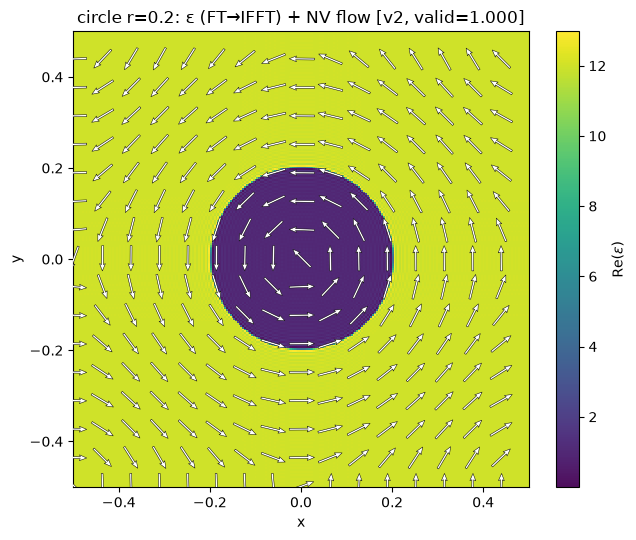

float32 (256, 256, 2) |v| mean 0.364873468875885
eps Re mean/min/max 10.617698669433592 0.0017455733781579497 12.977916924992304


In [2]:
lyr_circle = make_pattern_layer(make_circle_shape_s(0.2, [0.0, 0.0], 0.0, mat_pat))
vf_circle, eps_circle = plot_flow("circle r=0.2", lyr_circle)
print(vf_circle.dtype, vf_circle.shape, "|v| mean", float(np.mean(np.hypot(vf_circle[..., 0], vf_circle[..., 1]))))
print("eps Re mean/min/max", float(np.real(eps_circle).mean()), float(np.real(eps_circle).min()), float(np.real(eps_circle).max()))


## Rectangle

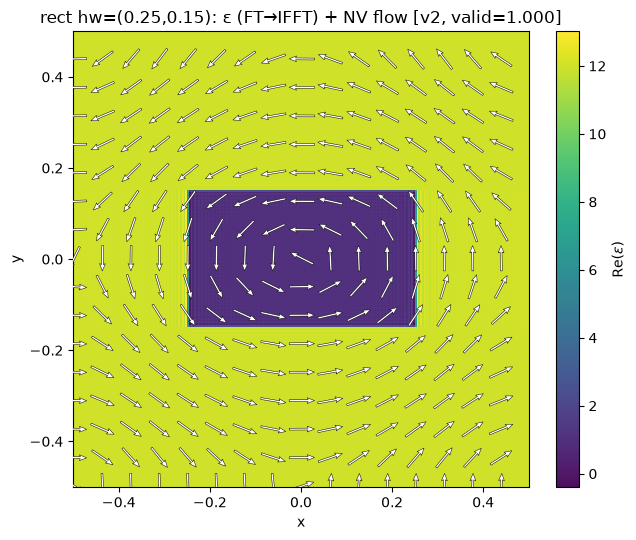

In [3]:
lyr_rect = make_pattern_layer(make_rect_shape_s([0.25, 0.15], [0.0, 0.0], 0.0, mat_pat))
_ = plot_flow("rect hw=(0.25,0.15)", lyr_rect)

## Ellipse

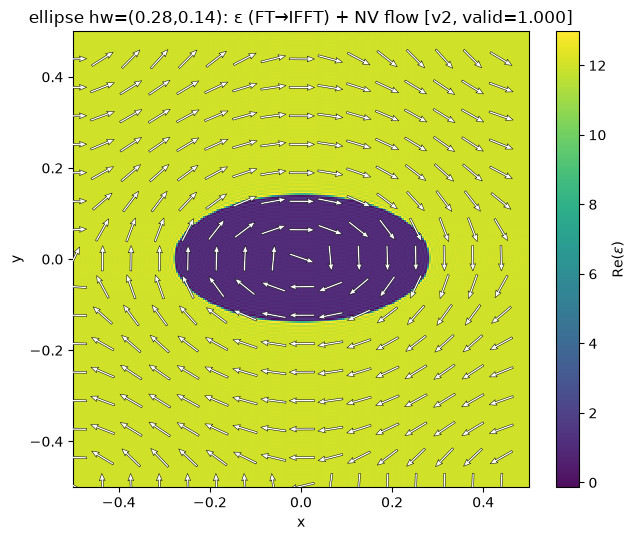

In [4]:
lyr_ell = make_pattern_layer(make_ellipse_shape_s([0.28, 0.14], [0.0, 0.0], 0.0, mat_pat))
_ = plot_flow("ellipse hw=(0.28,0.14)", lyr_ell)

## Triangle (polygon)

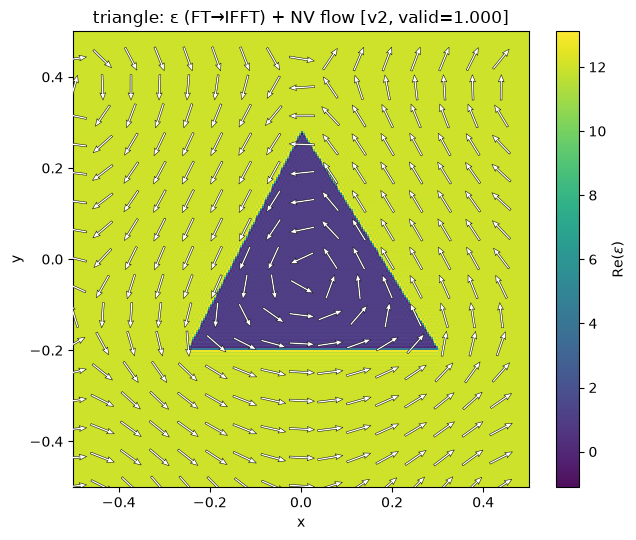

In [5]:
tri = [[-0.25, -0.2], [0.3, -0.2], [0.0, 0.28]]
lyr_tri = make_pattern_layer(make_poly_shape_s(tri, [0.0, 0.0], 0.0, mat_pat))
_ = plot_flow("triangle", lyr_tri)

## Donut（外圆 + 内圆；containment 由 S4 bridge 推断）

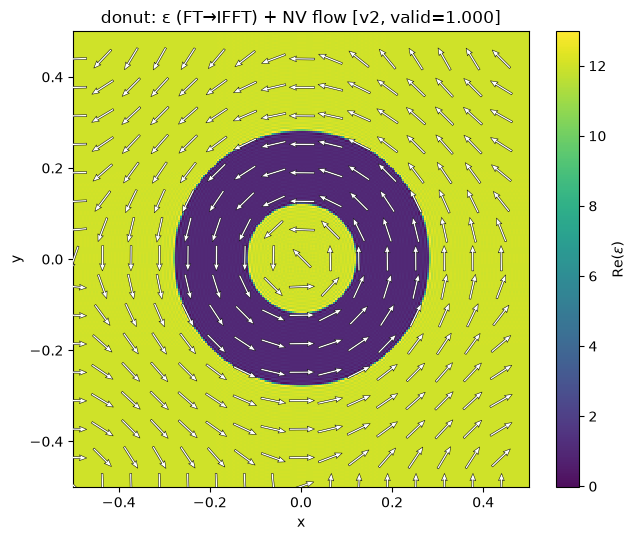

In [6]:
lyr_donut = make_pattern_layer(
    make_circle_shape_s(0.28, [0.0, 0.0], 0.0, mat_pat),
    (make_circle_shape_s(0.12, [0.0, 0.0], 0.0, mat_bg), 0),
)
_ = plot_flow("donut", lyr_donut)

## Multi（rect + 偏置 circle）

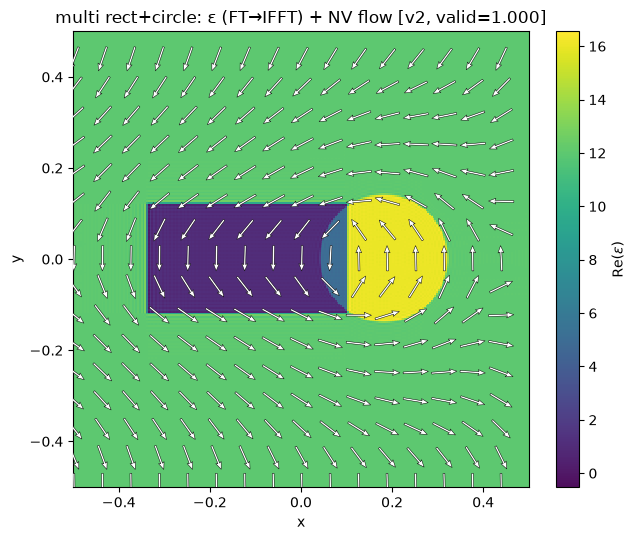

In [7]:
lyr_multi = make_pattern_layer(
    make_rect_shape_s([0.22, 0.12], [-0.12, 0.0], 0.0, mat_pat),
    make_circle_shape_s(0.14, [0.18, 0.0], 0.0, mat_hi),
)
_ = plot_flow("multi rect+circle", lyr_multi)